In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)

loader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 35.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.06MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.05MB/s]


In [3]:
class Generator(nn.Module):
    def __init__(self, z_dim=100):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(z_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.model(z)
        return x.view(-1, 1, 28, 28)

In [4]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(-1, 784)
        return self.model(x)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

opt_G = optim.Adam(G.parameters(), lr=0.0002)
opt_D = optim.Adam(D.parameters(), lr=0.0002)

In [6]:
epochs = 30
z_dim = 100

G_losses = []
D_losses = []

for epoch in range(epochs):
    g_loss_epoch = 0
    d_loss_epoch = 0

    for real, _ in loader:
        real = real.to(device)
        batch_size = real.size(0)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ---------------------
        # Train Discriminator
        # ---------------------
        z = torch.randn(batch_size, z_dim).to(device)
        fake = G(z)

        real_loss = criterion(D(real), real_labels)
        fake_loss = criterion(D(fake.detach()), fake_labels)

        d_loss = real_loss + fake_loss

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

        # ---------------------
        # Train Generator
        # ---------------------
        z = torch.randn(batch_size, z_dim).to(device)
        fake = G(z)

        g_loss = criterion(D(fake), real_labels)

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

        g_loss_epoch += g_loss.item()
        d_loss_epoch += d_loss.item()

    G_losses.append(g_loss_epoch / len(loader))
    D_losses.append(d_loss_epoch / len(loader))

    print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {D_losses[-1]:.4f} | G Loss: {G_losses[-1]:.4f}")

Epoch [1/30] | D Loss: 0.3737 | G Loss: 2.5821
Epoch [2/30] | D Loss: 0.2089 | G Loss: 4.2134
Epoch [3/30] | D Loss: 0.3942 | G Loss: 3.6455
Epoch [4/30] | D Loss: 0.4509 | G Loss: 3.6848
Epoch [5/30] | D Loss: 0.5325 | G Loss: 3.0127
Epoch [6/30] | D Loss: 0.6906 | G Loss: 2.7676
Epoch [7/30] | D Loss: 0.8186 | G Loss: 2.2809
Epoch [8/30] | D Loss: 0.7592 | G Loss: 2.2919
Epoch [9/30] | D Loss: 0.5112 | G Loss: 2.3725
Epoch [10/30] | D Loss: 0.3892 | G Loss: 2.6737
Epoch [11/30] | D Loss: 0.4951 | G Loss: 3.6518
Epoch [12/30] | D Loss: 0.5489 | G Loss: 3.1751
Epoch [13/30] | D Loss: 0.5826 | G Loss: 2.6092
Epoch [14/30] | D Loss: 0.4631 | G Loss: 3.0764
Epoch [15/30] | D Loss: 0.2594 | G Loss: 3.1674
Epoch [16/30] | D Loss: 0.2666 | G Loss: 3.3186
Epoch [17/30] | D Loss: 0.2565 | G Loss: 4.8487
Epoch [18/30] | D Loss: 0.2793 | G Loss: 4.0556
Epoch [19/30] | D Loss: 0.2868 | G Loss: 4.3647
Epoch [20/30] | D Loss: 0.1948 | G Loss: 4.5240
Epoch [21/30] | D Loss: 0.1956 | G Loss: 5.2829
E

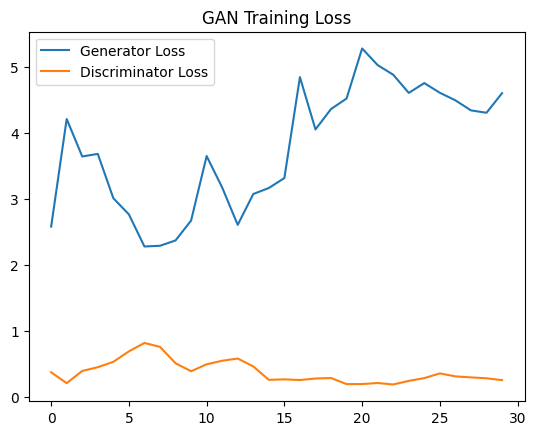

In [7]:
plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")
plt.legend()
plt.title("GAN Training Loss")
plt.show()

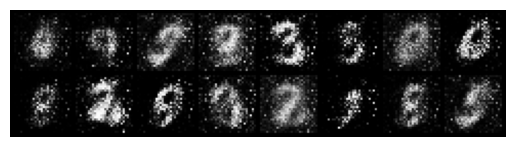

In [8]:
def show_generated(G, n=16):
    z = torch.randn(n, 100).to(device)
    fake = G(z).detach().cpu()

    grid = make_grid(fake, normalize=True)
    plt.imshow(np.transpose(grid, (1,2,0)))
    plt.axis('off')
    plt.show()

show_generated(G)